In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import os
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [70]:
df_hour = pd.read_csv('04_时段转化率.csv')
df_cat = pd.read_csv('03_品类转化率.csv')
df_funnel = pd.read_csv('02_漏斗分析.csv')
df_user = pd.read_csv('05_用户分层.csv')

In [72]:
print("时段数据形状:", df_hour.shape)
print("品类数据形状:", df_cat.shape)
print("用户数据形状:", df_user.shape)

时段数据形状: (24, 5)
品类数据形状: (10, 7)
用户数据形状: (20, 4)


In [74]:
df_funnel.columns = df_funnel.columns.str.strip()

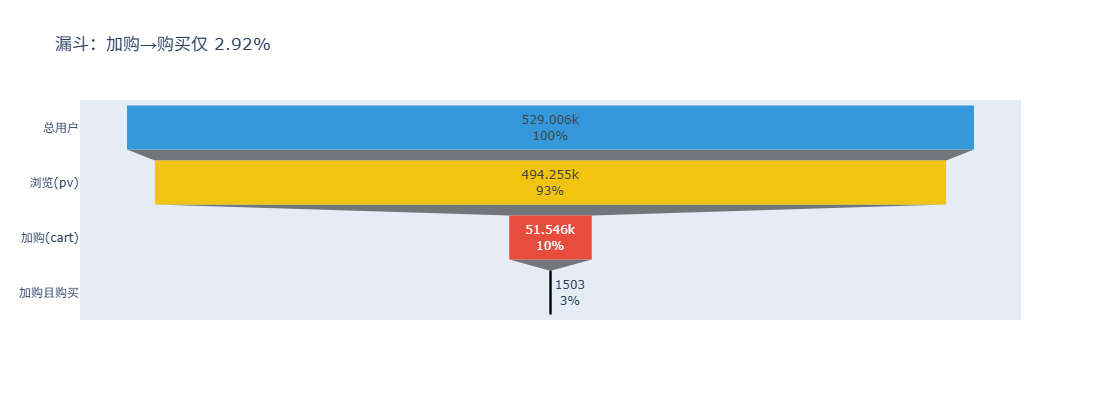

In [101]:
funnel_values = [
    df_funnel.loc[0, "total_users"],
    df_funnel.loc[0, "pv_users"],
    df_funnel.loc[0, "cart_users"],
    df_funnel.loc[0, "cart_and_buy_users"]
]
fig = go.Figure(go.Funnel(
    y = ["总用户","浏览(pv)", "加购(cart)", "加购且购买"],
    x = funnel_values,
    textinfo = "value+percent previous",
    marker = {"color": ["#3498db", "#f1c40f", "#e74c3c"]}
))
fig.update_layout(title=f"漏斗：加购→购买仅 {df_funnel.loc[0, 'cart_to_buy_rate']}%", width=700, height=400)
fig.show()

In [83]:
total_buy = df_funnel.loc[0, 'buy_users']
cart_buy = df_funnel.loc[0, 'cart_and_buy_users']
direct_buy = total_buy - cart_buy
direct_pct = (direct_buy / total_buy) * 100
cart_pct = (cart_buy / total_buy) * 100

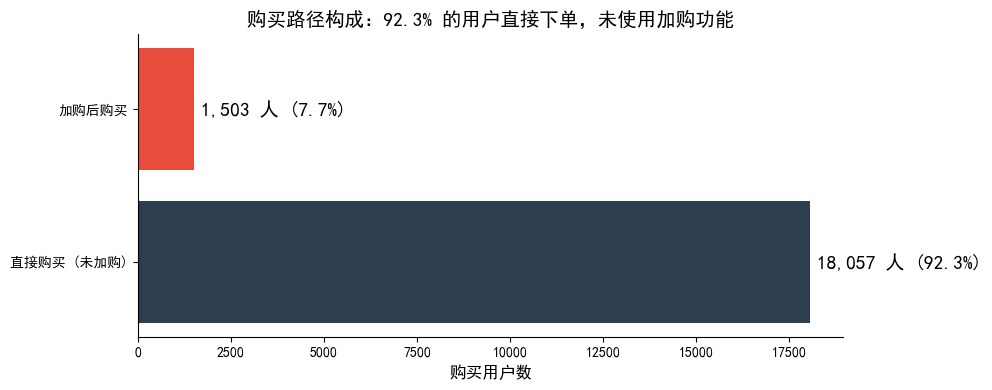

In [107]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    ['直接购买 (未加购)', '加购后购买'],
    [direct_buy, cart_buy],
    color=['#2c3e50', '#e74c3c']
)
for bar, pct in zip(bars, [direct_pct, cart_pct]):
    ax.text(
        bar.get_width() + 200,  # 偏移量，防止文字重叠
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():,.0f} 人 ({pct:.1f}%)',
        va='center',
        fontsize=14,
        fontweight='bold'
    )
ax.set_xlabel('购买用户数', fontsize=12)
ax.set_title('购买路径构成：92.3% 的用户直接下单，未使用加购功能', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("D:/科大/sql/项目/图/"+ "05_购买路径构成图.png", dpi=300)
plt.show()

In [120]:
df_hour.columns = df_hour.columns.str.strip()

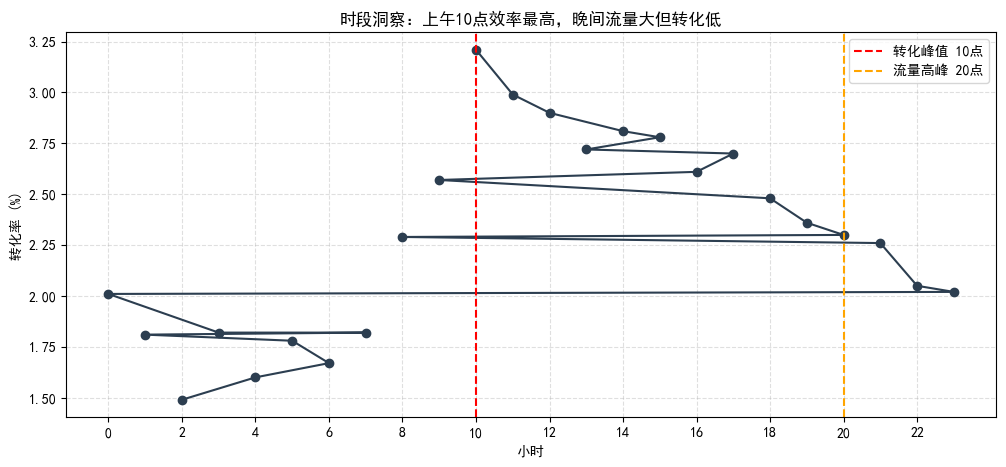

✅ 时段趋势图已生成


In [124]:
plt.figure(figsize=(12, 5))
plt.plot(df_hour["hour_of_day"], df_hour["conversion_rate"], marker='o', color='#2c3e50')
plt.axvline(x=10, color='red', linestyle='--', label='转化峰值 10点')
plt.axvline(x=20, color='orange', linestyle='--', label='流量高峰 20点')
plt.xlabel('小时')
plt.ylabel('转化率 (%)')
plt.title('时段洞察：上午10点效率最高，晚间流量大但转化低')
plt.xticks(range(0, 24, 2))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.savefig("D:/科大/sql/项目/图/" + "02_时段趋势图.png", dpi=300)
plt.show()
print("✅ 时段趋势图已生成")

In [126]:
df_cat.columns = df_cat.columns.str.strip()

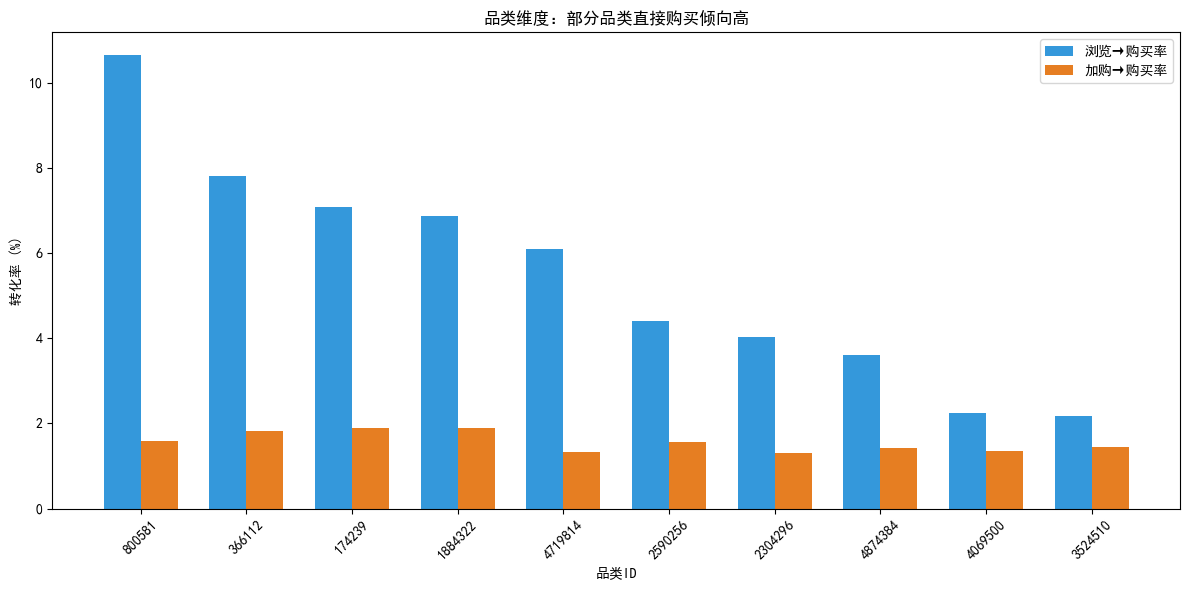

✅ 品类对比图已生成


In [130]:
df_cat_sorted = df_cat.sort_values('pv_to_buy_rate', ascending=False)
x = range(len(df_cat_sorted))
plt.figure(figsize=(12, 6))
plt.bar(x, df_cat_sorted["pv_to_buy_rate"], width=0.35, label='浏览→购买率', color='#3498db')
plt.bar([i+0.35 for i in x], df_cat_sorted["cart_to_buy_rate"], width=0.35, label='加购→购买率', color='#e67e22')
plt.xlabel('品类ID')
plt.ylabel('转化率 (%)')
plt.title('品类维度：部分品类直接购买倾向高')
plt.xticks([i+0.175 for i in x], df_cat_sorted["category_id"], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("D:/科大/sql/项目/图/" + "03_品类对比图.png", dpi=300)
plt.show()
print("✅ 品类对比图已生成")

In [132]:
df_user.columns = df_user.columns.str.strip()

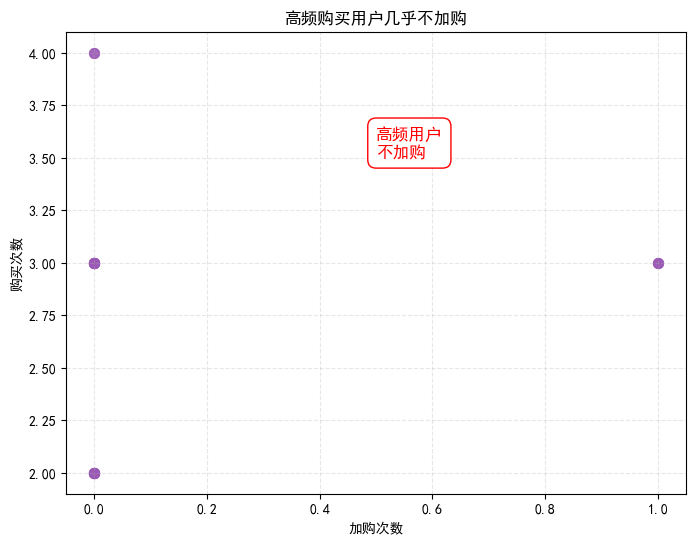

✅ 用户分层图已生成


In [136]:
plt.figure(figsize=(8, 6))
plt.scatter(df_user["cart_cnt"], df_user["buy_cnt"], s=50, alpha=0.7, color='#9b59b6')
plt.xlabel('加购次数')
plt.ylabel('购买次数')
plt.title('高频购买用户几乎不加购')
plt.grid(True, linestyle='--', alpha=0.3)
plt.text(0.5, 3.5, '高频用户\n不加购', fontsize=12, color='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.5'))
plt.savefig("D:/科大/sql/项目/图/" + "05_用户分层图.png", dpi=300)
plt.show()
print("✅ 用户分层图已生成")